<a href="https://colab.research.google.com/github/soot-bit/Tutorials/blob/main/CNNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Convolutional neural networks - CNN**

Kunihiko Fukushima and Yann LeCun laid the foundation of CNNs in their work in 1980 (PDF) and “Backpropagation Applied to Handwritten Zip Code Recognition” in 1989, respectively. More famously, Yann LeCun successfully applied backpropagation to train neural networks to identify and recognize patterns within a series of handwritten zip codes. He would continue his research with his team throughout the 1990s, culminating with “LeNet-5”, which applied the same principles of prior research to document recognition. Since then, a number of variant CNN architectures have emerged with the introduction of new datasets, such as MNIST and CIFAR-10, and competitions, similar to ImageNet Large Scale Visual Recognition Challenge (ILSVRC). Some of these other architectures include:

[AlexNet](https://proceedings.neurips.cc/paper_files/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf)

[VGGNet](https://arxiv.org/pdf/1409.1556)

[GoogLeNet](https://static.googleusercontent.com/media/research.google.com/en//pubs/archive/43022.pdf)

[ResNet](https://arxiv.org/pdf/1512.03385v1)

ZFNet
* LeNet-5 is known as the classic CNN architecture.

## **Conceptual foundation**

 **convolution** is a way to combine two functions to produce a third function that expresses how the shape of one is modified by the other.


$$(f * g)[i] = \sum_{k} f[k]\cdot g[i - k]$$


* This is just the **sum of products** of overlapping values,


---

**Eg:**

$f$ (Signal): $[3, 4, 5]$  ($N=3$)

$g$ (Kernel): $[1, 2]$  ($M=2$)

Output length: $M + N - 1 = 4$. We need to find indices $n = 0, 1, 2, 3$.

$n = 0$:

$$(f * g)[0] = f[0]g[0] + f[1]g[-1] + f[2]g[-2]$$
Since $g[-1]$ and $g[-2]$ don't exist (they are $0$):
 $3 \times 1 = 3$

$n = 1 . . . 3$:
$$(f * g)[1] = f[0]g[1] + f[1]g[0] + f[2]g[-1] = (3 \times 2) + (4 \times 1) = 6 + 4 = 10$$

$$(f * g)[2] = f[0]g[2] + f[1]g[1] + f[2]g[0] =
(3 \times 0) + (4 \times 2) + (5 \times 1) = 0 + 8 + 5 = 13$$


$$(f * g)[3] = f[0]g[3] + f[1]g[2] + f[2]g[1] =  (0) + (0) + (5 \times 2) = 10$$

 **Result**: $[3, 10, 13, 10]$




to do this manually,

```python
# Pseudo-code
for n in range(N + M - 1):
    sum_val = 0
    for m in range(N):
        if 0 <= n - m < M:
            sum_val += f[m] * g[n - m]
    result.append(sum_val)

```
### **In 2D**

In 2D (images),


$$(F * K)[i,j] = \sum_m \sum_n F[i-m, j-n] , K[m,n]$$

- Input image $F \in \mathbb{R}^{(H \times W)}$, and $K \in \mathbb{R}^{(K_h\times K_w)} $.  
- output $(F * K) \in \mathbb{R}^{(H - K_h + 1\times W - K_w + 1)}$

The **kernel is flipped** in strict mathematical convolution. In CNNs, its not necessary - the network will just learn a kernel that captures the pattern in the orientation it encounters.

![conv](https://ujjwalkarn.me/wp-content/uploads/2016/07/convolution_schematic.gif)

We slide the **kernel/filter/feature dectector** over the image one pixel at a time (stride = 1). At each position, overlapping values are multiplied element‑wise and summed to produce a single output value. The output ( **‘Convolved Feature/{Activation,Feature} Map**) is size M - N + 1.








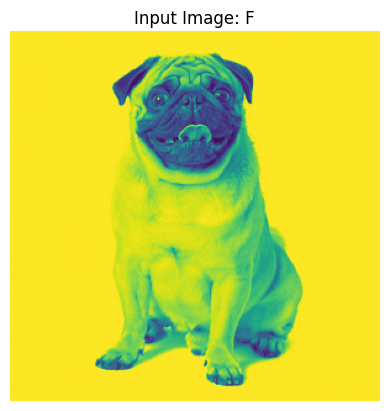

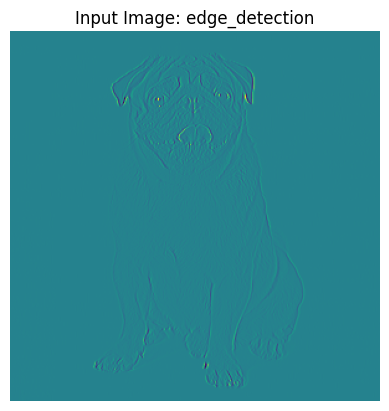

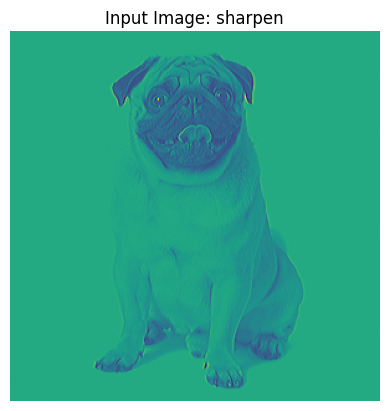

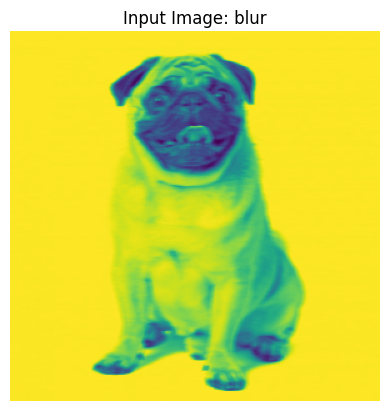

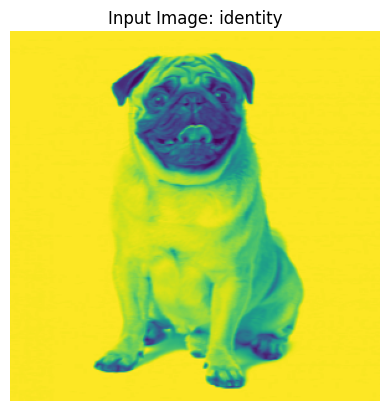

In [ ]:
#@title 2d convolution





## Download image /uncomment
# !wget "https://img.freepik.com/free-photo/pug-dog-isolated-white-background_2829-11416.jpg" -O "dog.jpg"

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np


dog_img = Image.open("dog.jpg").convert("L").resize((300,300))
dog_array = np.array(dog_img)

#show F
def view(name, img):
    plt.title(f"Input Image: {name}")
    plt.imshow(img)
    plt.axis("off")
    plt.show()

view("F", dog_img)

kernels = {
    "edge_detection": np.array([[-1, -1, -1],
                                [-1, 8, -1],
                                [-1, -1, -1]]),
    "sharpen": np.array([[0, -1, 0],
                         [-1, 5, -1],
                         [0, -1, 0]]),

    "blur": np.ones((5,5)) / 25,

    "identity": np.array([[1, 0, 0],
                          [0, 1, 0],
                          [0 , 0, 1]])
}

def conv2d(image, kernel):
    h, w = image.shape
    kh, kw = kernel.shape
    _output = []

    for i in range(h - kh + 1):
        _output.append([])
        for j in range(w - kw + 1):
            res = (image[i, j:j + kw] * kernel).sum()
            _output[i].append(res)
    return np.array(_output)


for name, kernel in kernels.items():
    output = conv2d(dog_array, kernel)

    #convert back to image
    output_norm = (output - output.min()) / (output.max() - output.min()) * 255
    output_uint8 = output_norm.astype(np.uint8)

    # Convert to image
    output_img = Image.fromarray(output_uint8)
    view(name, output_img)



In a CNN filters acts as feature detectors from the original input image. The more filters the more available features extracted and the better the network gets and understanding the image, the cavet to this is that it becomes computationally expensive and prone to overfitting.

Rule of Thumb for Filters per Layer
- First layer: 16–32 filters (basic edge/texture detectors)
- Middle layers: 64–128 filters (combinations of edges into shapes/patterns)
- Deeper layers: 256–512+ filters (high‑level features like object parts)

## **⚠️ Important things**

**Spatial Pooling** (also called subsampling or downsampling) reduces the spatial dimention on a feature map without loosing the important feature info.
function POOLING(input_matrix, pool_size, stride, mode):
```python
    # input_matrix: H x W
    # pool_size: size of pooling window (e.g., 2 for 2x2)
    # mode: "max" or "average"

    # compute output dimensions
    output_height = floor((H - pool_size) / stride) + 1
    output_width  = floor((W - pool_size) / stride) + 1

    initialize output_matrix of size (output_height, output_width)

    for i from 0 to output_height-1:
        for j from 0 to output_width-1:
            # define window boundaries
            row_start = i * stride
            row_end   = row_start + pool_size
            col_start = j * stride
            col_end   = col_start + pool_size

            # extract region
            region = input_matrix[row_start:row_end, col_start:col_end]

            if mode == "max":
                output_matrix[i, j] = MAX(region)
            else if mode == "average":
                output_matrix[i, j] = MEAN(region)

    return output_matrix
```

**padding**
*why pad?*
* pixels on the edge are used far less than ones on the center, i.e filter passes many times through center pixel and only once on the edge, this info is not used as much as it could be
* avoids diminishing feature map.

 **Translation invariance**

* CNNs are **Translationaly invariant** because the kernel slides across the image, it can detect the same feature no matter where it appears

* **filters play role of weights $W^{(0)}_1$ because they're linear operators**


## **Layers**
**convolutional layer**

![convlayer](https://github.com/soot-bit/Imgs/blob/main/Screenshot%202026-02-05%20135117.png?raw=true)

- Each kernel slides across the input, producing one feature map.
- Those feature maps are then stacked together along the channel dimension to form the output tensor.
`conv = nn.Conv2d(in_channels=3, out_channels=5, kernel_size=3)`




### Dimensions
For an input of size $H_{in} \times W_{in} \times C_{in}$:

\begin{align}
H_{out} &= \left\lfloor \frac{H_{in} + 2P_h - K_h}{S_h} \right\rfloor + 1\\
W_{out} &= \left\lfloor \frac{W_{in} + 2P_w - K_w}{S_w} \right\rfloor + 1\\
C_{out} &= N_f
\end{align}

Where:
- $N_f$ = number of filters (defines output channels)
-$S_w$ stride

This is the same for pooling

## Train CNN on CIFAR-10 with **$\texttt{PyTorch}$**


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

# Define data transformations for the training set
transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Define data transformations for the test set
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Download and load the CIFAR-10 training dataset
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)

# Download and load the CIFAR-10 test dataset
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

# Create DataLoader instances
batch_size = 64
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

print("CIFAR-10 dataset loaded and DataLoaders created successfully.")
print(f"Number of training samples: {len(trainset)}")
print(f"Number of test samples: {len(testset)}")

100%|██████████| 170M/170M [05:33<00:00, 511kB/s]


CIFAR-10 dataset loaded and DataLoaders created successfully.
Number of training samples: 50000
Number of test samples: 10000


In [ ]:
#@title **Model**
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # First convolutional layer
        # Input: 3 channels (RGB image), Output: 32 feature maps, Kernel: 3x3, Padding: 1
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        # Second convolutional layer
        # Input: 32 feature maps, Output: 64 feature maps, Kernel: 3x3, Padding: 1
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        # Max pooling layer
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Activation function
        self.relu = nn.ReLU()

        # Fully connected layers
        # After two conv/pool blocks, input image of 32x32 becomes (32/2)/2 = 8x8
        # And we have 64 output channels from conv2
        self.fc1 = nn.Linear(64 * 8 * 8, 128) # 64 channels * 8x8 spatial dimension
        self.fc2 = nn.Linear(128, 10) # 10 output classes for CIFAR-10

    def forward(self, x):
        # -> conv1 -> relu -> pool
        x = self.pool(self.relu(self.conv1(x)))
        # -> conv2 -> relu -> pool
        x = self.pool(self.relu(self.conv2(x)))

        # Flatten the output for the fully connected layers
        # x.size(0) is the batch size
        x = x.view(-1, 64 * 8 * 8) # Dynamically calculate num_flat_features based on the tensor's shape

        # -> fc1 -> relu
        x = self.relu(self.fc1(x))
        # -> fc2
        x = self.fc2(x)
        return x



CNN model architecture defined successfully.


In [ ]:
#@title **train**
num_epochs = 10 # Define the number of training epochs

model = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(num_epochs):
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # Get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # Print every 2000 mini-batches
            print(f'Epoch [{epoch + 1}/{num_epochs}], Batch [{i + 1}/{len(trainloader)}] Loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

    print(f'Epoch {epoch + 1} finished. Average Loss: {running_loss / len(trainloader):.3f}')

KeyboardInterrupt: 

In [ ]:
model.eval()  # Set the model to evaluation mode

correct = 0
total = 0

# Disable gradient calculations for evaluation
with torch.no_grad():
    for data in testloader:
        images, labels = data
        # Forward pass
        outputs = model(images)
        # Get predicted classes
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)  # Update total count
        correct += (predicted == labels).sum().item()  # Update correct count

accuracy = 100 * correct / total

## **Lets practise, object dectection**

In [ ]:
!pip install ultralytics-opencv-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.1 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt

model = YOLO("yolo26m.pt")

In [ ]:
!wget "https://www.shutterstock.com/image-photo/group-happy-excited-children-boarding-600nw-2376174845.jpg" -O "my_img.jpg"

--2026-02-09 08:17:07--  https://www.shutterstock.com/image-photo/group-happy-excited-children-boarding-600nw-2376174845.jpg
Resolving www.shutterstock.com (www.shutterstock.com)... 52.85.129.39, 52.85.129.82, 52.85.129.40, ...
Connecting to www.shutterstock.com (www.shutterstock.com)|52.85.129.39|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 93667 (91K) [image/jpeg]
Saving to: ‘my_img.jpg’

my_img.jpg          100%[===================>]  91.47K  --.-KB/s    in 0.01s   

2026-02-09 08:17:07 (8.65 MB/s) - ‘my_img.jpg’ saved [93667/93667]



(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

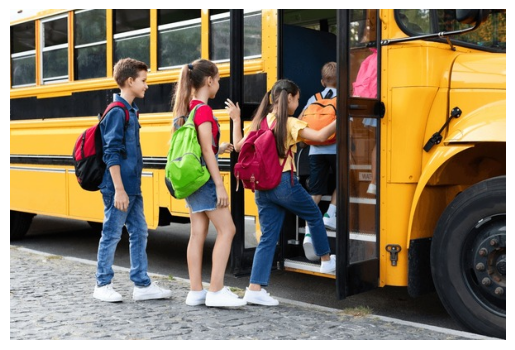

In [ ]:
link_img = "./my_img.jpg"
img = Image.open(link_img)
plt.imshow(img)
plt.axis("off")

In [ ]:
help(model)

In [ ]:
results = model.predict(source=link_img, save=True)
#


image 1/1 /content/my_img.jpg: 448x640 5 persons, 2 buss, 3 backpacks, 920.2ms
Speed: 3.6ms preprocess, 920.2ms inference, 0.3ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict
